# Generación de columnas

Técnica utilizada en problemas lineales de **gran escala** donde se tiene un **número de variables gigantezco**. 

La intuición detrás de esto es que, en vez de resolver un LP completo, se intenta resolver de forma iterativa un problema con pocas variables e ir *"creando"* nuevas columnas/variables.

Primero, consideremos un problema LP completo:

$$\min\sum_{j\in\mathcal{J}}c_jx_j\;\;\text{s.a}\;\;Ax=b\;\;x\geq 0$$ 

La idea es formar un problema **maestro** donde utilizamos un subconjunto $\mathcal{J}'\subset\mathcal{J}$. Este problema llega a una solución primal $x$ y duales $\pi$ para $Ax=b$.

Existirá un **costo reducido** (*recordar el algoritmo [simplex](https://es.wikipedia.org/wiki/Símplex)*) para una columna candidata, de la forma 

$$\bar{c_j}=c_j-\pi^{T}a_j$$

Recordando que, en problemas de minimización, si $\bar{c_j}<0$, entonces la columna podría **mejorar el objetivo**. Por lo tanto, conviene **añadirla al problema maestro**. 

Así, en vez de buscar columnas *"a mano"*, lo planteamos como un subproblema:

$$\min_{j\;\text{posibles}}\bar{c_j}=c_j-\pi^{T}a_j$$

Claramente, si $\bar{c_j}$ no da negativo, entonces estamos en el óptimo. 

## *Cutting stock problem*

Es un problema utilizado amplicamente en industria de cortes; por ejemplo, se tiene una productora de metal que produce barras largas y se tiene que desenglosar en barras cortas.

Se tiene un rollo madre de tamaño $L$ (el stock). Además, se tiene distintas demandas por el rollo en trozos más chicos. Se quiere ver cómo cortar el rollo madre tal que se cumpla la demanda, minimizando la cantidad total de rollos madres.

Asumamos que tenemos un rollo madre con $L=110$, y las demandas $\lbrace (2\times 50),(1\times 45); (1\times 20)\rbrace$ que representa la demanda de 2 piezas de 50 de largo, una pieza de 45, etc. 

Existen varios patrones para cortar el rollo de $110$, por ejemplo: 

- Patrón $A$: $50+50$, se ocupan $100$ y sobra $10$.
- Patrón $B$: $50+45$, se ocupa $95$ y sobra $15$.
- Patrón $C$: $45+20+20$, se ocupa $85$, sobra $25$.
- Patrón $D$: $20+20+20+20+20$, se ocupa $100$ y sobra $10$.

El problema está en escoger cómo cortar cada rollo grande, minimizando el número de rollos grandes utilizados. 

### Formulación matemática 

Sea:

- $L$: La longitud del rollo grande
- $m$: El número de tipos de piezas diferentes
- Para cada tipo, nos definimos $l_i$ la longitud de la pieza $i$ y $d_i$ la demanda de la pieza.

Adicionalmente, nos definimos patrones de cortes $p$, por ejemplo, $p_1 = (2,1,0)$ significa usar 2 piezas del tipo $1$, $1$ del tipo $2$ y $0$ del tipo $3$. Así, $a_{ip}$ es el número de piezas de tipo $i$ que se obtienen del patrón $p$. Además, $x_p\in\mathbb{Z}$ es el número de veces que se usa el patrón $p$. 

Por lo tanto, la función objetivo es minimizar el número de rollos grandes usados, o en defecto, minimizar los patrones utilizados:

$$\min\sum_p x_p$$

Sujeto que cada tipo de pieza debe cumplir su demanda

$$\sum_p a_{ip}x_p\geq d_i\;\;\;\;\forall i,\dots, m$$ 

Además, cada patrón debe respetar la longitud máxima del rollo:

$$\sum_{i=1}^{m}l_ia_{ip}\leq L\;\;\;\;\forall p$$

### Generación de columnas 

Del problema es posible notar que la cantidad de combinaciones $p$ es enorme. Por lo mismo, la intuición está por partir con un conjunto acotado de soluciones y luego ir expandiendo el conjunto.

El problema maestro llegaría a ser:

$$\min\sum_p x_p\;\text{s.a}\;\sum_pa_{ip}x_p\geq d_i$$

Partamos con un pequeño ejemplo de motivación: 

Sea $L=110$ con $L_1=50$ con una demanda de $d_1=4$ unidades y $L_2=20$ con una demanda de $d_2=6$ unidades.

Arranquemos el problema con dos patrones únicamente:

- $P_1=[2,0]$
- $P_2=[0,5]$

Así, el LP quedaría como

$$
\begin{aligned}
\min x_1+x_2&\\ \\
2x_1&\geq 4\\ \\
5x_2&\geq 6\\ \\
x_1,x_2&\geq 0
\end{aligned}
$$

Con solución $x_1=2, x_2=1.2$. 

Es posible formular el dual y darnos cuenta que:

- Para $P_1=[2,0]$, la restricción dual es $2\pi_1\leq 1\implies\pi_1\leq 0.5$
- Para $P_2=[0,5]$ la restricción dual es $5\pi_2\leq 1\implies \pi_2\leq 0.2$

En el óptimo, ambas restricciones estarán activas. Por lo tanto, cortar una pieza de $50$ vale $0.5$ en el dual y una de $20$ vale $0.2$. La idea es encontrar un patrón que cobre más que su costo $1$. 

Así, buscamos maximizar $\pi_1a_1+\pi_2a_2\iff 50a_1+20a_2\leq 110$. El costo reducido llegaría a ser $1-(\pi_1a_1+\pi_2a_2)$.

Es posible probar con el patrón $a_1=1$ y $a_2 = 3$ (equivalente a tener $[1,3]$. El costo reducido llegaría a ser negativo $(-0.1)$, entonces, al problema maestro le añadimos el nuevo patrón $P_3=[1,3]$.

Se tendría el siguiente problema:

$$
\begin{aligned}
\min x_1+x_2+x_3&\\ \\
2x_1+1x_3&\geq 4\\ \\
5x_2+3x_3&\geq 6
\end{aligned}
$$

Es posible generarnos una instancia "ficticia" con la función `generar_instancia_CSP`

In [86]:
from helpers import generar_instancia_CSP, plotear_instancia_CSP 

inst = generar_instancia_CSP(
        n_types=6,
        stock_length=110,
        width_range=(10, 60),
        demand_range=(5, 30),
        tightness=0.7,
        seed=42,
        name="Instancia simple",
    )

print("Instancia:", inst.name)
print("L =", inst.stock_length)
for it in inst.items:
    print(" Tipo{}: largo={}, demanda={}".format(it.id, it.width, it.demand))
print("Demanda total de largos=", inst.total_width_demand())

Instancia: Instancia simple
L = 110
 Tipo0: largo=33, demanda=5
 Tipo1: largo=40, demanda=12
 Tipo2: largo=15, demanda=28
 Tipo3: largo=11, demanda=28
 Tipo4: largo=51, demanda=7
 Tipo5: largo=31, demanda=6
Demanda total de largos= 1916


Luego, mostrar como se visualizan los patrones con la función `plotear_instancia_CSP`

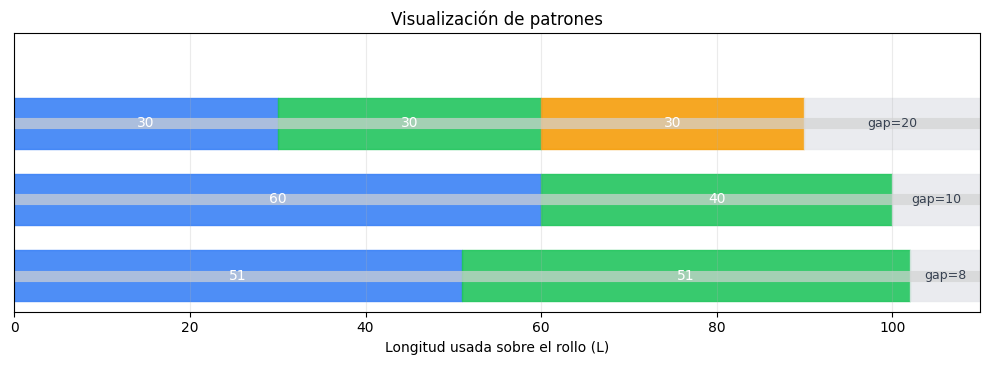

In [87]:

patrones = [
    [51, 51],      # 100 usado, gap 10
    [60, 40],      # 100 usado, gap 10
    [30, 30, 30],  # 90 usado, gap 20
]
plotear_instancia_CSP(inst, patterns=patrones, title="Visualización de patrones")

Así, para resolver el problema maestro, que es un problema lineal, utilizaremos el solver de `or-tools`. 

In [88]:
from ortools.linear_solver import pywraplp

def construir_RMP(inst, patrones):
    """
    Construye el Restricted Master Problem (relajado).

    Parámetros:
    ----------
    inst: Objeto importado de helpers, que guarda la instancia
    patrones: Lista de lista con los patrones [a_1, ..., a_m]

    Retorna:
    --------
    Una tupla con el solver, el valor de las variables de decisión y las restricciones
    """
    solver = pywraplp.Solver.CreateSolver("GLOP")  # LP continuo
    m = len(inst.items)

    # variables x_k: rollos de cada patrón
    x = [solver.NumVar(0.0, solver.infinity(), f"x_{k}") for k in range(len(patrones))] # Una variable de decisión por patrón

    # objetivo: minimizar cantidad total de rollos
    solver.Minimize(solver.Sum(x))

    # restricciones de demanda
    constraints = []
    for i, it in enumerate(inst.items):
        c = solver.Add(solver.Sum(pat[i] * x[k] for k, pat in enumerate(patrones)) >= it.demand)
        constraints.append(c)

    return solver, x, constraints


Por el otro lado, nos definimos el subproblema, como un problema tipo knapsack, puesto que es de la forma:

$$\max\sum_i\pi_i a_i\;\;\text{s.a}\;\;\sum_iw_ia_i\leq L\;\;y_i\in\mathbb{Z}_+$$

$$\min\text{Costos reducidos}$$

In [15]:
def resolver_subproblema(inst, duales):
    """
    Resuelve el subproblema de pricing (entero).
    Devuelve patrón y valor objetivo.
    """
    solver = pywraplp.Solver.CreateSolver("SCIP")  # MIP
    m = len(inst.items)
    L = inst.stock_length

    # variables enteras: cantidad de piezas de cada tipo
    y = [solver.IntVar(0, solver.infinity(), f"y_{i}") for i in range(m)]

    # objetivo: maximizar suma dual_i * y_i
    solver.Maximize(solver.Sum(duales[i] * y[i] for i in range(m)))

    # restricción de mochila
    solver.Add(solver.Sum(inst.items[i].width * y[i] for i in range(m)) <= L)

    status = solver.Solve()
    if status != pywraplp.Solver.OPTIMAL:
        raise RuntimeError("Subproblema no resolvió.")

    patron = [int(y[i].solution_value()) for i in range(m)]
    valor = solver.Objective().Value()
    return patron, valor

Así, nos podemos definir el algoritmo principal de generación de columnas:

In [89]:
def generacion_columnas(inst, max_iters=20, plot=True):
    m = len(inst.items)

    # patrones iniciales: uno por tipo
    patrones = []
    for i, it in enumerate(inst.items):
        p = [0]*m
        p[i] = inst.stock_length // it.width
        patrones.append(p)

    iteracion = 0
    while iteracion < max_iters:
        print(f"\n--- Iteración {iteracion} ---")

        # maestro
        solver, x, constraints = construir_RMP(inst, patrones)
        solver.Solve()
        
        print("  Solución RMP (relajada):")
        for k, var in enumerate(x):
            if var.solution_value() > 1e-6:
                print(f"    {var.name()} = {var.solution_value():.3f}")

        # obtener duales
        duales = [c.DualValue() for c in constraints]
        print("  Duales:", [f"{d:.3f}" for d in duales])

        # subproblema
        patron, valor = resolver_subproblema(inst, duales)
        costo_reducido = 1 - valor
        print("  Patrón candidato:", patron, f" | Valor={valor:.3f}, Costo reducido={costo_reducido:.3f}")

        if costo_reducido < -1e-6:
            print("Se agrega el patrón al maestro")
            patrones.append(patron)
            # gráfico de progreso
            if plot:
                rolls = []
                for i, q in enumerate(patron):
                    rolls += [inst.items[i].width]*q
                plotear_instancia_CSP(inst, [rolls], title=f"Iter {iteracion}: nuevo patrón")
        else:
            print(" No hay mejora, se detiene")
            break

        iteracion += 1

    # resolver maestro final
    solver, x, constraints = construir_RMP(inst, patrones)
    solver.Solve()

    sol = {x[k].name(): x[k].solution_value() for k in range(len(x))}
    print("\n=== Solución final ===")
    print("Número de rollos (relajado):", solver.Objective().Value())

    return patrones, sol, solver.Objective().Value()

Por lo tanto, veamos como funciona la generación de columnas.


--- Iteración 0 ---
  Solución RMP (relajada):
    x_0 = 2.000
    x_1 = 10.000
    x_2 = 5.778
    x_3 = 3.714
  Duales: ['0.333', '0.500', '0.111', '0.071']
  Patrón candidato: [0, 2, 2, 0]  | Valor=1.222, Costo reducido=-0.222
Se agrega el patrón al maestro


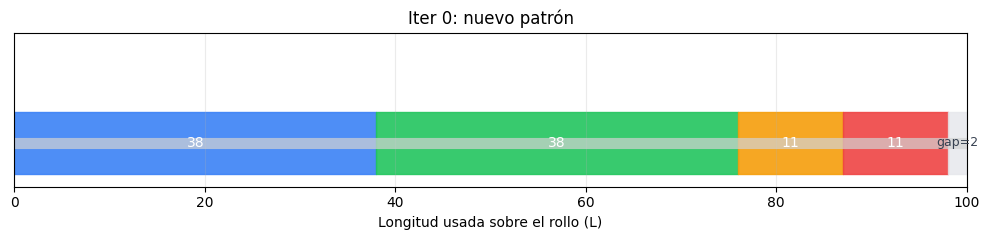


--- Iteración 1 ---
  Solución RMP (relajada):
    x_0 = 2.000
    x_2 = 3.556
    x_3 = 3.714
    x_4 = 10.000
  Duales: ['0.333', '0.389', '0.111', '0.071']
  Patrón candidato: [3, 0, 0, 1]  | Valor=1.071, Costo reducido=-0.071
Se agrega el patrón al maestro


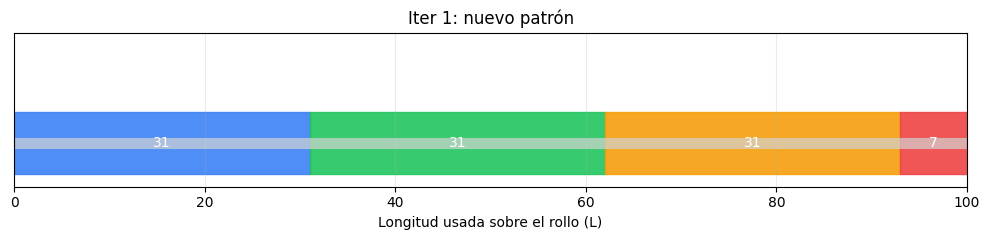


--- Iteración 2 ---
  Solución RMP (relajada):
    x_2 = 3.556
    x_3 = 3.571
    x_4 = 10.000
    x_5 = 2.000
  Duales: ['0.310', '0.389', '0.111', '0.071']
  Patrón candidato: [0, 1, 5, 1]  | Valor=1.016, Costo reducido=-0.016
Se agrega el patrón al maestro


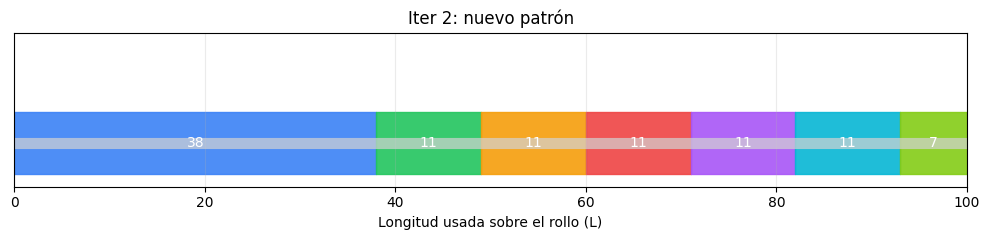


--- Iteración 3 ---
  Solución RMP (relajada):
    x_3 = 3.000
    x_4 = 6.000
    x_5 = 2.000
    x_6 = 8.000
  Duales: ['0.310', '0.393', '0.107', '0.071']
  Patrón candidato: [2, 1, 0, 0]  | Valor=1.012, Costo reducido=-0.012
Se agrega el patrón al maestro


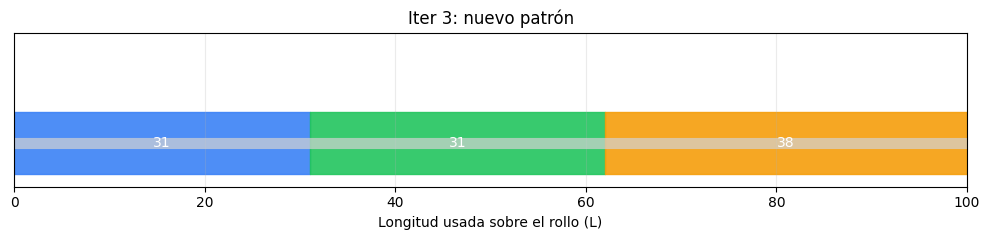


--- Iteración 4 ---
  Solución RMP (relajada):
    x_3 = 3.089
    x_4 = 4.125
    x_6 = 8.750
    x_7 = 3.000
  Duales: ['0.304', '0.393', '0.107', '0.071']
  Patrón candidato: [0, 0, 0, 14]  | Valor=1.000, Costo reducido=-0.000
 No hay mejora, se detiene

=== Solución final ===
Número de rollos (relajado): 18.964285714285715


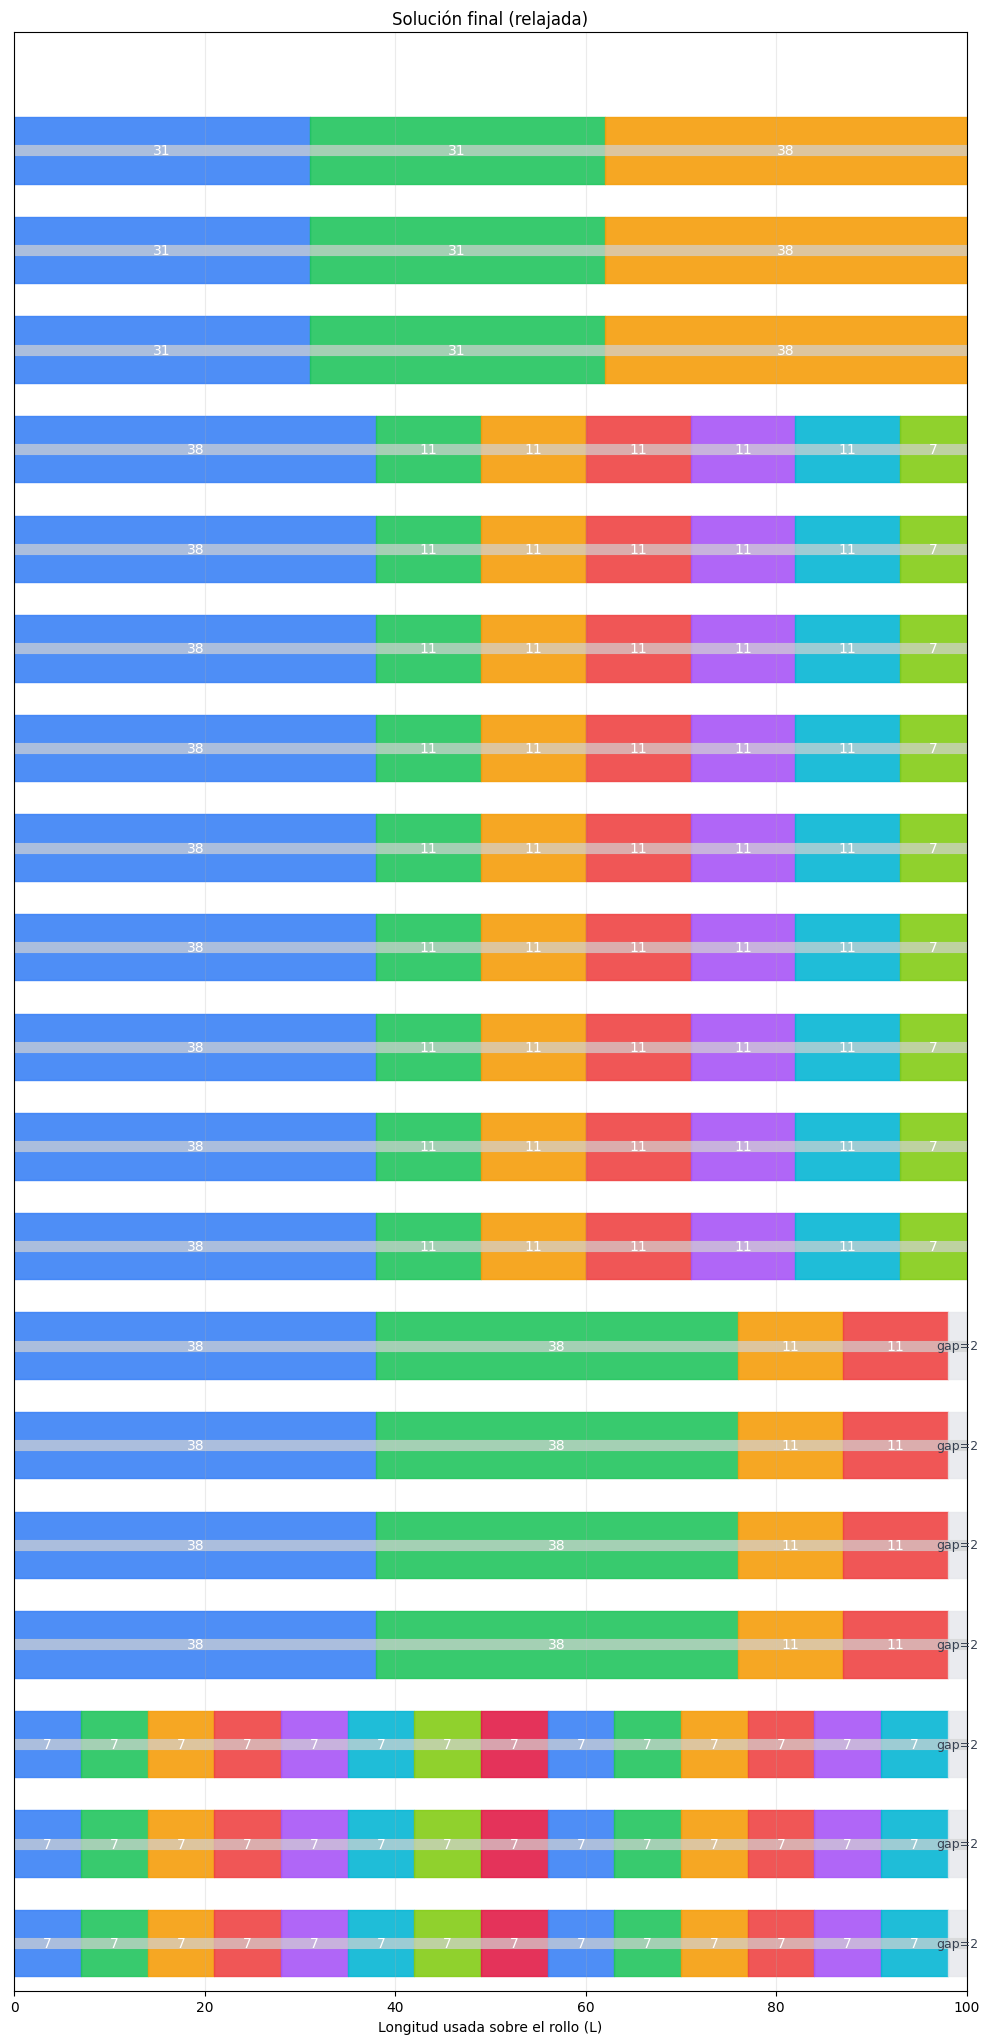

In [17]:
inst = generar_instancia_CSP(n_types=4, stock_length=100, seed=42)

patrones, sol, rolls = generacion_columnas(inst)

# Expandir y graficar la solución final
patrones_expand = []
for pat, (var, val) in zip(patrones, sol.items()):
    for _ in range(int(round(val))):
        roll = []
        for i, q in enumerate(pat):
            roll += [inst.items[i].width]*q
        patrones_expand.append(roll)

plotear_instancia_CSP(inst, patrones_expand, title="Solución final (relajada)")

# Relajación Lagrangeana

Sea un problema del estilo 

$$
\begin{aligned}
p^*&=\min f(x)\\ \\
g(x)&\leq 0\\ \\
h(x)&= 0
\end{aligned}
$$

Es posible relajar algunas restricciones difíciles, añadiendo una penalización en la función objetivo:

$$
\begin{aligned}
v^*(\lambda)&=\min f(x)+\lambda^Th(x)\\ \\
g(x)&\leq 0
\end{aligned}
$$

## Knapsack problem

Asumamos que tenemos un problema del estilo:

$$
\begin{aligned}
\max\ &\sum_j p_j x_j \\ \\
\text{s.a.}\ &\sum_j w_j x_j \leq C \\ \\
&x_j \in \{0,1\}, \quad \forall j
\end{aligned}
$$

La **relajación lagrangiana** consiste en mover la restricción de capacidad al objetivo con un multiplicador $\lambda \geq 0\$:

$$
L(\lambda) = \max_{x \in \{0,1\}^n} \left\{ \sum_j p_j x_j + \lambda \Big(C - \sum_j w_j x_j \Big) \right\}.
$$ 

Esto se puede reescribir como:

$$
L(\lambda) = \lambda C + \max_{x \in \{0,1\}^n} \sum_j (p_j - \lambda w_j) x_j.
$$

El subproblema se descompone ítem por ítem. Así, cada variable se decide de manera independiente:

$$
x_j(\lambda) = 
\begin{cases}
1 & \text{si } p_j - \lambda w_j > 0, \\
0 & \text{en otro caso.}
\end{cases}
$$

Como $L(\lambda)$ siempre relaja la restricción, provee una **cota superior** del óptimo verdadero.  
Por lo tanto, el problema dual lagrangiano se formula como:

$$
\min_{\lambda \geq 0} \; \lambda C + \sum_{j : p_j > \lambda w_j} (p_j - \lambda w_j).
$$

O, de forma equivalente:

$$
\begin{aligned}
\min\ & \lambda C + \sum (p_j - \lambda w_j) \\
\text{s.a. } & p_j > \lambda w_j, \\
& \lambda \geq 0.
\end{aligned}
$$

Para ver esto en la práctica, nos generamos un generador de instancias para el problema del knapsack

In [51]:
import math
import random
from dataclasses import dataclass

random.seed(7)

@dataclass
class KPInstance:
    p: List[int]   # beneficios
    w: List[int]   # pesos
    C: int         # capacidad

def generar_instancia_knapsack(
    n: int = 50,
    rango_w=(10, 60),
    capacity_ratio: float = 0.30,
    ruido_p=(0, 10),
    seed: int = 0,
) -> KPInstance:
    """
    Genera una instancia 'dura' de knapsack:
    - Capacidad tensa: C ≈ capacity_ratio * sum(w)
    - Beneficios correlacionados con el peso: p_j = w_j + ruido (ratios similares)
    
    Parámetros
    ----------
    n : número de ítems
    rango_w : tupla (min_w, max_w) para pesos
    capacity_ratio : fracción de sum(w) usada como capacidad (0.2–0.35 es duro)
    ruido_p : tupla (a, b) para ruido entero agregado al beneficio
    seed : semilla RNG

    Devuelve
    --------
    KPInstance(p, w, C)
    """
    rng = random.Random(seed)
    w = [rng.randint(*rango_w) for _ in range(n)]
    C = max(1, int(capacity_ratio * sum(w)))  # capacidad apretada
    p = [wj + rng.randint(*ruido_p) for wj in w]
    idx = list(range(n))
    rng.shuffle(idx)
    w = [w[i] for i in idx]
    p = [p[i] for i in idx]
    return KPInstance(p=p, w=w, C=C)

def valor_y_peso(p, w, x):
    val = sum(pi*xi for pi, xi in zip(p, x))
    wt  = sum(wi*xi for wi, xi in zip(w, x))
    return val, wt

Nos definimos una función que resolverá el subproblema lagrangiano:

$$L(\lambda)=\max_{x\in\lbrace 0,1\rbrace^n} (\sum_j p_jx_j+\lambda(C-\sum_jw_jx_j))$$ 

Esto devolverá el vector $x(\lambda)$ relajado, el valor $L(\lambda)$ y el subgradiente $g(\lambda)=C-\sum_jw_jx_j(\lambda)$

In [23]:
def solucion_relajada_lambda(p, w, C, lam):
    """
    Dado lambda, resuelve el subproblema lagrangiano:
      L(λ) = lambda C + sum_j max(0, p_j - lambda w_j)
    y devuelve (x_relajada, L(λ), subgradiente g = C - sum w_j x_j).
    """
    n = len(p)
    x = [0]*n # Inicializamos el vector de soluciones
    # Selección independiente por ítem
    for j in range(n):
        if p[j] - lam*w[j] > 0:
            x[j] = 1 # Si cumple la condición, estará activa
    # L(\lambda)
    L = lam * C + sum(max(0.0, p[j] - lam*w[j]) for j in range(n)) # Valor de la función objetivo
    # subgradiente (para min en \lambda):
    g = C - sum(w[j]*x[j] for j in range(n)) # Subgradiente
    return x, L, g

Ahora, algo a notar es que la solución $x(\lambda)$ puede llegar a violar la capacidad (al tener peso mayor que $C$). Por lo mismo, nos definimos una función heurística para construir una solución factible, eliminando ítems hasta cumplir la restricción. 

Lo que haremos es eliminar ítems con el peor ratio beneficio peso $(p_j/w_j)$

In [24]:
def reparar_a_factible(p, w, C, x):
    """
    Heurística de reparación:
    - Si el peso excede C: eliminar ítems en orden de peor 'ratio' p_j/w_j (de menor a mayor)
      hasta cumplir C.
    """
    n = len(p)
    val, wt = valor_y_peso(p, w, x)
    x = x[:]  # copia

    # Si excede, eliminar desde peor ratio
    if wt > C:
        items = [(p[j]/w[j], j) for j in range(n) if x[j] == 1 and w[j] > 0]
        items.sort()  # de peor a mejor
        for _, j in items:
            if wt <= C:
                break
            x[j] = 0
            val -= p[j]
            wt  -= w[j]

    # Si queda espacio, intentar llenar por mejor ratio
    if wt < C:
        items = [(p[j]/w[j], j) for j in range(n) if x[j] == 0 and w[j] > 0]
        items.sort(reverse=True)  # de mejor a peor
        for _, j in items:
            if wt + w[j] <= C:
                x[j] = 1
                val += p[j]
                wt  += w[j]

    return x, val, wt

Por último, nos definimos una función que implementa el algoritmo de subgradiente para resolver el dual lagrangeano. 

Básicamente, mantiene la mejor cota superior $UB$ encontrada (mínimo de $L(\lambda)$) y la mejor cota inferior encontrada (mejor solución factible reparada). 

Así, se realiza un método de subgradiente:

$$\lambda_{k+1}=\max\lbrace 0,\lambda_k-\alpha_k g_k\rbrace$$ 

Con un paso del estilo **Polyak**:

$$\alpha_k=\tau\cdot\frac{UB-LB}{\lvert\lvert g_k\rvert\rvert^2}$$ 

In [45]:

def lagrangiano_subgradiente(inst: KPInstance, 
                             max_iter: int = 300, 
                             tau: float = 2.0,
                             verbose: bool = True):
    """
    Minimiza L(lambda) por subgradientes.
    - Mantiene mejor cota superior UB = min L(lambda)
    - Construye LB (mejor factible) reparando x(lambda).
    - Paso Polyak aproximado
    """
    p, w, C = inst.p, inst.w, inst.C
    lam = 0.0 # lambda inicial
    UB = float('inf') # mejor cota superior (min L)
    LB = 0.0 # mejor cota inferior (mejor factible)
    best_L = None # Par (lambda, L(\lambda)) con la mejor última solución
    best_x_rel = None # última solución relajada
    best_x_fact = None # Mejor solución factible

    for k in range(1, max_iter+1):
        x_rel, Lval, g = solucion_relajada_lambda(p, w, C, lam)

        if Lval < UB:
            UB = Lval
            best_L = (lam, Lval)

        # reparar para obtener factible y actualizar LB
        x_fact, val_fact, wt_fact = reparar_a_factible(p, w, C, x_rel)
        if val_fact > LB:
            LB = val_fact
            best_x_fact = x_fact

        # paso subgradiente
        gnorm2 = g*g
        if gnorm2 == 0:
            if verbose:
                print(f"[iter {k}] g=0 -> paro")
            break

        # Polyak-like (si UB < +inf)
        if math.isfinite(UB) and LB > -1e18:
            step = tau * max(UB - LB, 0.0) / max(gnorm2, 1e-12)
        else:
            step = tau / math.sqrt(k)  # fallback

        lam = max(0.0, lam - step * g)

        if verbose and (k % 25 == 0 or k == 1):
            print(f"[iter {k:3d}] λ={lam:.4f}  L(λ)={Lval:.4f}  UB={UB:.4f}  LB={LB:.4f}  g={g:.1f}")

        best_x_rel = x_rel

        # Criterio de paro simple
        if math.isfinite(UB) and abs(UB - LB) <= 1e-6:
            if verbose:
                print(f"[iter {k}] UB se aproxima a LB -> paro")
            break

    return {
        "lambda": lam,
        "UB": UB,
        "LB": LB,
        "best_relaxed": best_x_rel,
        "best_feasible": best_x_fact,
        "best_L": best_L,
    }

Para comparar como rinde nuestro algoritmo, nos podemos definir un óptimo exacto que funciona para instancias pequeñas

In [46]:
def knapsack_optimo_dp(p, w, C): 
    """
    DP 0/1 clásico por capacidad O(n*C).
    Devuelve (valor_optimo, x_opt).
    """
    n = len(p)
    DP = [0]*(C+1)
    # backtracking: guardar decisiones
    choice = [[0]*(C+1) for _ in range(n)]
    for i in range(n):
        wi, pi = w[i], p[i]
        for cap in range(C, wi-1, -1):
            if DP[cap - wi] + pi > DP[cap]:
                DP[cap] = DP[cap - wi] + pi
                choice[i][cap] = 1  # tomé el item i
    # reconstrucción
    x = [0]*n
    cap = C
    for i in range(n-1, -1, -1):
        if choice[i][cap] == 1:
            x[i] = 1
            cap -= w[i]
    return DP[C], x

Por lo tanto, ejecutemos un experimento para ver como funciona: 

In [53]:
inst = generar_instancia_knapsack(
    n=40,
    rango_w=(20, 80),
    capacity_ratio=0.1,
    ruido_p=(0, 5),
    seed=123
)
print(f"n={len(inst.p)}, C={inst.C}")
print("Primeros ítems (p,w):", list(zip(inst.p[:8], inst.w[:8])))

# Resolver lagrangiano
res = lagrangiano_subgradiente(inst, max_iter=300, tau=0.1, verbose=True)

# Evaluar soluciones
val_rel, wt_rel = valor_y_peso(inst.p, inst.w, res["best_relaxed"])
val_fac, wt_fac = valor_y_peso(inst.p, inst.w, res["best_feasible"])

print("\n=== RESULTADOS LAGRANGIANOS ===")
print(f"Mejor λ       : {res['best_L'][0]:.4f} (L(λ)={res['best_L'][1]:.2f})")
print(f"Cota superior : UB = {res['UB']:.2f}")
print(f"Mejor factible: LB = {res['LB']:.2f}  (peso={wt_fac} ≤ C={inst.C})")

# Comparación exacta (si C no es enorme)
opt_val, x_opt = knapsack_optimo_dp(inst.p, inst.w, inst.C)
print("\n=== ÓPTIMO (DP) ===")
print(f"Valor óptimo  : {opt_val:.2f}")
gap = (res["UB"] - opt_val) / max(1.0, opt_val) * 100
gap_lb = (opt_val - res["LB"]) / max(1.0, opt_val) * 100
print(f"Gap(UB vs OPT): {gap:.2f}%   |   Gap(LB vs OPT): {gap_lb:.2f}%")

n=40, C=180
Primeros ítems (p,w): [(45, 41), (52, 48), (47, 44), (30, 25), (37, 37), (57, 55), (78, 75), (70, 69)]
[iter   1] λ=0.1055  L(λ)=1920.0000  UB=1920.0000  LB=205.0000  g=-1626.0
[iter  25] λ=0.9790  L(λ)=341.7994  UB=341.7994  LB=205.0000  g=-1626.0
[iter  50] λ=1.1001  L(λ)=215.9901  UB=215.9901  LB=205.0000  g=-151.0
[iter  75] λ=1.0733  L(λ)=221.3007  UB=214.2621  LB=205.0000  g=-377.0
[iter 100] λ=1.0562  L(λ)=230.3701  UB=214.2295  LB=205.0000  g=-668.0
[iter 125] λ=1.0434  L(λ)=240.0395  UB=214.2252  LB=205.0000  g=-850.0
[iter 150] λ=1.0888  L(λ)=217.4506  UB=214.2252  LB=205.0000  g=-208.0
[iter 175] λ=1.0658  L(λ)=224.4965  UB=214.2252  LB=205.0000  g=-599.0
[iter 200] λ=1.0539  L(λ)=231.9056  UB=214.2252  LB=205.0000  g=-668.0
[iter 225] λ=1.0435  L(λ)=239.9303  UB=214.2252  LB=205.0000  g=-850.0
[iter 250] λ=1.0890  L(λ)=217.4176  UB=214.2252  LB=205.0000  g=-208.0
[iter 275] λ=1.0660  L(λ)=224.3834  UB=214.2252  LB=205.0000  g=-599.0
[iter 300] λ=1.0541  L(λ)=231

# Gurobi y callbacks

Gurobi es uno de los solvers más potentes para problemas de optimización matemática. Sirven para Programación Lineal (LP), Programación Entera Mixta (MIP/MILP), Programación Cuadrática (QP/QCQP) y Programación con Restricciones Cónicas (SOCP). 

Su implementación está en el estado del arte y se necesita **una licencia** para poder ser usadas. Afortunadamente, cuenta [con una licencia académica](https://www.gurobi.com/academia/academic-program-and-licenses/?utm_source=google&utm_medium=cpc&utm_campaign=M3+A+Search+SA+Brand&gad_source=1&gad_campaignid=22845995659&gbraid=0AAAAADimQ3g13K8sCMZNvPGzxPEvmX6Mu&gclid=CjwKCAjwisnGBhAXEiwA0zEOR6QVeY3nyQTs4NDr259euKa2xCVqCzpgZxKbcugWnWN7MsYXcMdayxoCkzEQAvD_BwE) para el uso académico. 

Gurobi está compuesto por: 

1. **Front-end**: Donde definimos el modelo (variables, restricciones, función objetivo).
2. **Motor de optimización**: encargado de aplicar algoritmos (Simplex, Branch-and-Bound, etc)
3. **Interfaz de usuario**: APIs en Python, C, C++, Java, etc. 

## *¿Cómo funciona Gurobi por dentro?*

Para problemas enteros mixtos (MIP), Gurobi aplica **Branch-and-Bound** con:

- **Heuristicas** para encontrar soluciones factibles
- **Cortes**
- **Presolve** para reducir el tamaño del modelo
- **Paralelismo** para explorar el árbol de busqueda más rápido.

El usuario puede ajustar parámetros, como `MIPGap`, `TimeLimit`, `Heuristics`, **o intervenir directamente durante la optimización con callbacks**.

## *¿Qué son los callbacks?*

Una función que la define el usuario, que Gurobi llama en **momento específicos**. Esto permite:

- Monitorear el progreso de la solución
- Agregar restricciones de corte
- Agregar soluciones factibiles propuestas por el usuario
- Tomar decisiones personalizadas

## Tipos de callbacks

- `MIPNODE`: Cuando Gurobi está procesando un nodo del árbol de búsqueda
- `MIPSOL`: Cuando encuentra una solución factible
- `MESSAGE`: Cuando imprime un mensaje

Partamos con un ejemplo básico. Definámonos un modelo simple de un problema de dos mochilas:

In [82]:
import gurobipy as gp
from gurobipy import GRB

rng = random.Random(7)
n = 400
profit = [rng.randint(10, 60) for _ in range(n)]
w1 = [rng.randint(8, 25)  for _ in range(n)]
w2 = [rng.randint(6, 20)  for _ in range(n)]

C1 = int(0.28 * sum(w1))
C2 = int(0.30 * sum(w2))

m = gp.Model() # Nuestro modelo 

x = m.addVars(n, vtype=GRB.BINARY, name = "x") # añadir las variables binarias

# Maximizamos el beneficio
m.setObjective(gp.quicksum(profit[i] * x[i] for i in range(n)), GRB.MAXIMIZE)

m.addConstr(gp.quicksum(w1[i] * x[i] for i in range(n)) <= C1, name="knap1")
m.addConstr(gp.quicksum(w2[i] * x[i] for i in range(n)) <= C2, name="knap2")

# Conflictos locales: no tomar vecinos simultáneamente (camino)
for i in range(n - 1):
    m.addConstr(x[i] + x[i+1] <= 1, name=f"conflict_{i}")


Podemos editar cómo queremos que Gurobi utilice las heurísticas con `m.setParam("Heuristics", x)` donde `x` es un decimal del 0 al 1.0, que indica la fracción del tiempo que dedica al cómputo de heurísticas.

Por lo mismo, naturalmente, es posible desactivar heurísticas con `m.setParam("Heuristics", 0.0)`.

In [83]:
m.setParam("Heuristics", 0.0)

Set parameter Heuristics to value 0


Existen otros `setParam` para otras cosas, como límite de tiempo, tolerancia, etc.

In [84]:
m.setParam("TimeLimit", 60)
m.setParam("MIPGap", 0)

Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0


En las próximas clases veremos que se puede aplicar varios parámetros para el algoritmo de **Branch and Bound**, que se verá más en profundidad. 

Definamos nuestro primer callback

In [85]:

def my_callback(model, where):
    # "where" indica en qué etapa del solver estamos
    if where == GRB.Callback.MIPSOL:
        # Se encontró una nueva solución entera factible
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        print(f"\nNueva solución encontrada con valor objetivo = {obj:.2f}\n")

    if where == GRB.Callback.MIPNODE:
        # Estamos evaluando un nodo del árbol
        best_bound = model.cbGet(GRB.Callback.MIPNODE_OBJBST)   # mejor cota
        best_obj   = model.cbGet(GRB.Callback.MIPNODE_OBJBND)   # mejor solución factible
        print(f"\nNodo: mejor factible = {best_obj}, mejor cota = {best_bound}\n")

m.optimize(my_callback)

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0

Optimize a model with 401 rows, 400 columns and 1598 nonzeros
Model fingerprint: 0xcc82d4f2
Variable types: 0 continuous, 400 integer (400 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+01, 6e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+03]
Presolve removed 2 rows and 1 columns
Presolve time: 0.01s
Presolved: 399 rows, 399 columns, 1592 nonzeros
Variable types: 0 continuous, 399 integer (399 binary)

Root relaxation: objective 6.036254e+03, 107 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 6036.25424    0    2     